In [88]:
%matplotlib inline

from datetime import datetime, timedelta
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from utils import process

files = Path("./data").glob("*.txt")
most_recent = sorted(files)[-1]

df = pd.DataFrame(process(most_recent)).set_index("datetime").sort_index()
df["solve_number"] = range(1, df.shape[0]+1)

df["session_id"] =df["session_id"].astype(int)

cutoff = datetime.now() + timedelta(days=-7)

df["in_last_week"] = df.index >= cutoff
df

,session_id,state,time_ms,solve_number,in_last_week
datetime,,,,,
2026-02-09 08:43:35,1,0,46034,1,False
2026-02-09 08:50:55,1,0,59276,2,False
2026-02-09 08:55:29,1,-1,54276,3,False
2026-02-09 09:04:18,1,0,68041,4,False
2026-02-10 12:51:13,2,-1,19919,5,False
...,...,...,...,...,...
2026-02-26 10:29:57,17,0,32157,219,True
2026-02-26 10:32:33,17,0,30288,220,True
2026-02-26 10:35:26,17,0,40355,221,True


In [89]:
# map sessions to cubes
cubes = {
    1: "Rubik's",
    2: "MoYu WRM v9",
    3: "MoYu WRM v10",
}

# start session: cube
cubemap = {
    1: 1,
    16: 2,
}

bins = [*cubemap.keys(), np.inf]
labels = [cubes[cubemap[k]] for k in cubemap]

df["cube"] = pd.cut(df.session_id, bins=bins, labels=labels, right=False, ordered=False)

In [90]:
# filter to valid times and calculate averages

valid_times = df[df.state == 0]

def trimmed_mean(series: pd.Series, skip=1):
    """Calculates average of n by removing the best & worst values (determined by param skip, symmetrically)
        i.e. n=5, skip=1 will calculate the mean of the 3 middle values of 5
    """
    sorted = np.sort(series)
    return sorted[skip:-skip].mean()

def rolling_ao(series: pd.Series, n=5, skip=1):
    return series.rolling(n).apply(trimmed_mean, raw=True)


valid_times["ma10"] = valid_times.time_ms.rolling(window=10).mean()
valid_times["ao5"] = rolling_ao(valid_times.time_ms, 5, 1)
valid_times["ao12"] = rolling_ao(valid_times.time_ms, 12, 1)
valid_times["ao100"] = rolling_ao(valid_times.time_ms, 100, 5)


valid_times["is_pb"] = valid_times.time_ms.cummin() == valid_times.time_ms

valid_times.tail()


,session_id,state,time_ms,solve_number,in_last_week,cube,ma10,ao5,ao12,ao100,is_pb
datetime,,,,,,,,,,,
2026-02-26 10:29:57,17,0,32157,219,True,MoYu WRM v9,35805.4,37321.333333,36804.8,39326.959184,False
2026-02-26 10:32:33,17,0,30288,220,True,MoYu WRM v9,35645.1,37321.333333,35253.6,39264.724490,False
2026-02-26 10:35:26,17,0,40355,221,True,MoYu WRM v9,36832.3,38832.000000,35568.0,39307.153061,False
2026-02-26 10:37:39,17,0,35757,222,True,MoYu WRM v9,36751.0,36089.666667,35954.6,39275.326531,False
2026-02-26 10:40:37,17,0,36371,223,True,MoYu WRM v9,35808.1,34761.666667,36743.4,39298.469388,False


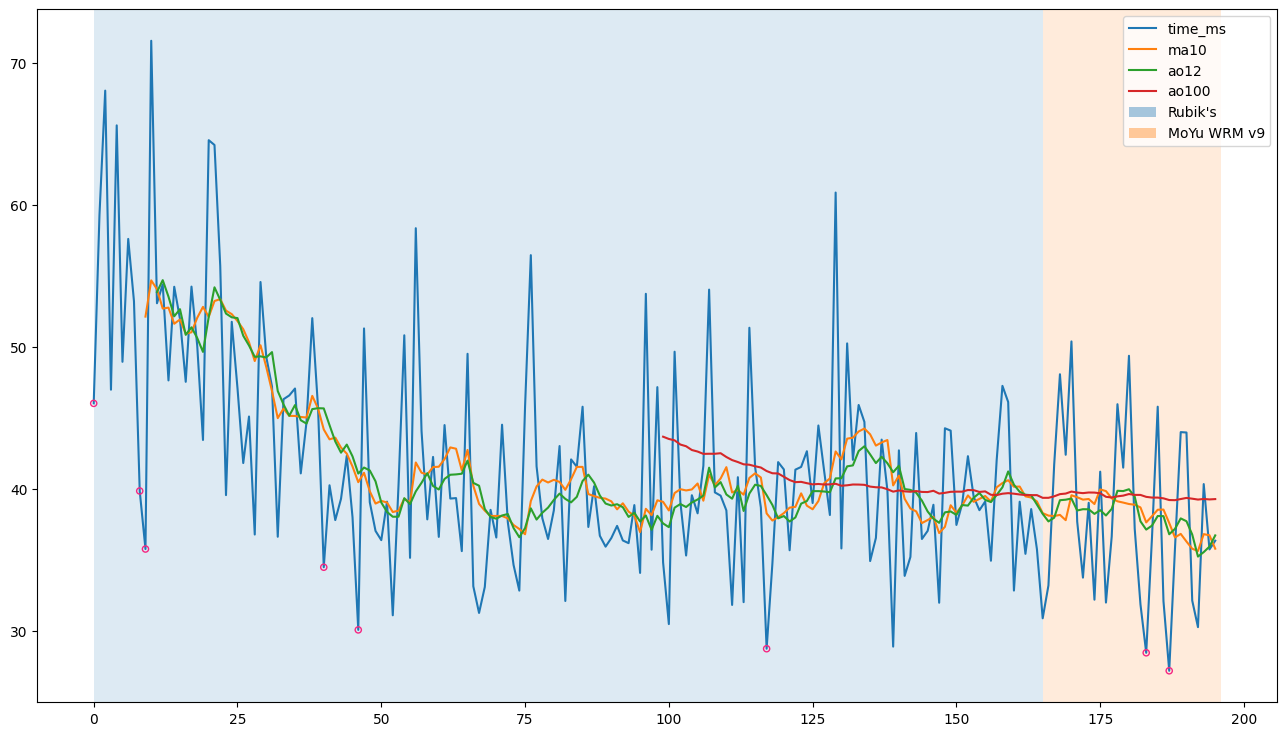

In [92]:
# plot times
columns = [
    "time_ms",
    "ma10",
    # "ao5",
    "ao12",
    "ao100",
]


ax = (valid_times[columns] / 1000).reset_index(drop=True).plot.line(figsize=(16,9))

# highlight PBs
mask = valid_times.is_pb.values
x_positions = np.where(mask)[0]

ax.scatter(
    x_positions,
    valid_times.loc[mask, "time_ms"]/1000,
    facecolors='none',
    edgecolors="#f62681",
    linewidths=1,
    zorder=5,
    s=20,
    marker="o"
)

# background color by cube
cubes = valid_times.cube.reset_index(drop=True)
colors = {category: plt.cm.tab10(i) for i, category in enumerate(cubes.unique())}
changes = cubes.ne(cubes.shift()).to_numpy().nonzero()[0].tolist() + [len(cubes)]

for start, end in zip(changes, changes[1:]):
    ax.axvspan(start, end, alpha=.15, color = colors[cubes.iloc[start]], lw=0)

# set up labels
from matplotlib.patches import Patch
cube_handles = [Patch(facecolor=colors[cat], alpha=0.4, label=cat) for cat in cubes.unique()]
line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(handles=line_handles + cube_handles, labels=line_labels + list(cubes.unique()))

plt.show()


In [93]:
best_time = valid_times.time_ms.min()

print(f"Best: {best_time / 1000}")

(valid_times.time_ms / 1000).describe()

(valid_times[valid_times.in_last_week].time_ms / 1000).describe()

Best: 27.217


count    151.000000
mean      39.397689
std        6.055013
min       27.217000
25%       35.717000
50%       38.702000
75%       42.291500
max       60.869000
Name: time_ms, dtype: float64

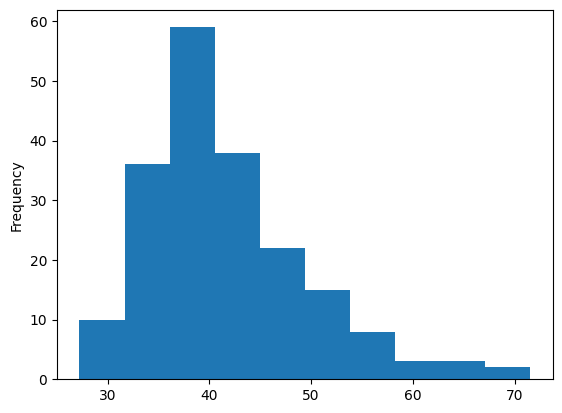

In [94]:
(valid_times.time_ms / 1000).plot.hist()
plt.show()

In [95]:
# PBs
valid_times[valid_times.is_pb]

,session_id,state,time_ms,solve_number,in_last_week,cube,ma10,ao5,ao12,ao100,is_pb
datetime,,,,,,,,,,,
2026-02-09 08:43:35,1,0,46034,1,False,Rubik's,NaN,NaN,NaN,NaN,True
2026-02-11 15:50:05,3,0,39869,13,False,Rubik's,NaN,53262.333333,NaN,NaN,True
2026-02-11 15:51:53,3,0,35784,14,False,Rubik's,52138.3,47350.000000,NaN,NaN,True
2026-02-17 17:54:25,7,0,34503,51,False,Rubik's,44198.6,43862.666667,45679.4,NaN,True
2026-02-19 19:05:10,8,0,30094,59,True,Rubik's,40488.8,38387.666667,41094.9,NaN,True
2026-02-21 10:30:39,12,0,28769,144,True,Rubik's,38291.0,37428.333333,39577.9,41273.193878,True
2026-02-26 10:07:46,17,0,28483,210,True,MoYu WRM v9,37657.9,36871.000000,37152.2,39455.612245,True
2026-02-26 10:15:31,17,0,27217,214,True,MoYu WRM v9,37615.9,32390.333333,36823.7,39231.724490,True
